# ⚡ Knowledge Distillation: LightGBM Teacher → LightGBM Student
## Hourly Energy Consumption | MLOps

Este notebook substitui o antigo pipeline de Deep Learning (LSTM -> TCN) por um pipeline extremamente veloz usando Árvores de Decisão (LightGBM). A ideia da **Knowledge Distillation (KD)** em modelos de árvore (Pseudo-Labeling) consiste em treinar um modelo super-complexo (*Teacher*) e usar as previsões dele no conjunto de treino como o alvo suavizado (*Soft Targets*) para um modelo muito simples (*Student*).

**O objetivo é atestar se o Student treinado com KD supera o Student treinado sem KD.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import kagglehub
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)



## 1. Carregamento do Dataset

In [2]:
print("Carregando dataset...")
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
df_raw = pd.read_csv(f"{path}/AEP_hourly.csv")

df = df_raw.copy()
datetime_col = 'Datetime'
target_col = 'AEP_MW'

df[datetime_col] = pd.to_datetime(df[datetime_col])
df = df.sort_values(datetime_col).reset_index(drop=True)
df = df.dropna(subset=[target_col])

# Usamos apenas os últimos 3 anos para treino rápido
cutoff = df[datetime_col].max() - pd.DateOffset(years=3)
df = df[df[datetime_col] >= cutoff].reset_index(drop=True)

print(f"Período: {df[datetime_col].min()} → {df[datetime_col].max()}")
print(f"Shape: {df.shape}")


Carregando dataset...


  0%|          | 0.00/11.4M [00:00<?, ?B/s]

  9%|▉         | 1.00M/11.4M [00:00<00:07, 1.42MB/s]

 18%|█▊        | 2.00M/11.4M [00:00<00:03, 2.83MB/s]

 35%|███▌      | 4.00M/11.4M [00:00<00:01, 6.04MB/s]

 70%|███████   | 8.00M/11.4M [00:01<00:00, 12.9MB/s]

100%|██████████| 11.4M/11.4M [00:01<00:00, 17.8MB/s]

100%|██████████| 11.4M/11.4M [00:01<00:00, 10.1MB/s]

Extracting files...


Período: 2015-08-03 00:00:00 → 2018-08-03 00:00:00
Shape: (26305, 2)


## 2. Feature Engineering (Achatar a Série Temporal)
Como árvores não têm "memória" como uma rede LSTM, criamos features de *Lags* e Extrações de *Data*.

In [3]:
df_feat = df.copy()

# Features Temporais
df_feat['hour'] = df_feat[datetime_col].dt.hour
df_feat['dayofweek'] = df_feat[datetime_col].dt.dayofweek
df_feat['month'] = df_feat[datetime_col].dt.month
df_feat['dayofyear'] = df_feat[datetime_col].dt.dayofyear

# Lags (Histórico imediato)
for i in [1, 2, 3, 24, 48, 168]: # Lags de até 1 semana atrás
    df_feat[f'lag_{i}'] = df_feat[target_col].shift(i)

# Rolling Means
df_feat['roll_mean_24'] = df_feat[target_col].rolling(24).mean().shift(1)
df_feat['roll_mean_168'] = df_feat[target_col].rolling(168).mean().shift(1)

df_feat = df_feat.dropna().reset_index(drop=True)

# Split Treino / Teste (Teste = Últimos 2 meses)
test_size = 24 * 60
train = df_feat.iloc[:-test_size]
test = df_feat.iloc[-test_size:]

features = [c for c in df_feat.columns if c not in [datetime_col, target_col]]
X_train = train[features]
y_train = train[target_col]
X_test = test[features]
y_test = test[target_col]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (24697, 12), Test size: (1440, 12)


## 3. Teacher Model (Complex LightGBM)
Um modelo profundo, que pode sofrer algum overfitting, mas decora muito bem os padrões de treinamento.

In [4]:
teacher = lgb.LGBMRegressor(
    n_estimators=1500,
    max_depth=-1,
    num_leaves=255,
    learning_rate=0.01,
    random_state=42
)
teacher.fit(X_train, y_train)

# Gerando Soft Targets (Pseudo-labels) no conjunto de Treinamento!
# A mágica da destilação em árvores é treinar o estudante com ESTA variável suavizada, e não com y_train.
y_train_soft = teacher.predict(X_train)

preds_teacher = teacher.predict(X_test)
mae_teacher = mean_absolute_error(y_test, preds_teacher)
print(f"MAE Teacher: {mae_teacher:.2f} MW")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2339
[LightGBM] [Info] Number of data points in the train set: 24697, number of used features: 12
[LightGBM] [Info] Start training from score 14617.963599


MAE Teacher: 119.94 MW


## 4. Student-NoKD (Ablation Control)
Um modelo extremamente raso, treinado contra o alvo normal/ruidoso (`y_train`). Este é o nosso Baseline.

In [5]:
student_nokd = lgb.LGBMRegressor(
    n_estimators=50,
    max_depth=4,
    num_leaves=15,
    random_state=42
)
# Treina no GROUND TRUTH
student_nokd.fit(X_train, y_train)

preds_nokd = student_nokd.predict(X_test)
mae_nokd = mean_absolute_error(y_test, preds_nokd)
print(f"MAE Student-NoKD: {mae_nokd:.2f} MW")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2339
[LightGBM] [Info] Number of data points in the train set: 24697, number of used features: 12
[LightGBM] [Info] Start training from score 14617.963599
MAE Student-NoKD: 204.69 MW


## 5. Student-KD (Knowledge Distillation)
A exata mesma arquitetura rasa, porém treinada contra os Soft Targets (`y_train_soft`) gerados pelo Teacher.

In [6]:
student_kd = lgb.LGBMRegressor(
    n_estimators=50,
    max_depth=4,
    num_leaves=15,
    random_state=42
)
# TREINA NO SOFT TARGET (O Conhecimento Destilado)
student_kd.fit(X_train, y_train_soft)

preds_kd = student_kd.predict(X_test)
mae_kd = mean_absolute_error(y_test, preds_kd)
print(f"MAE Student-KD: {mae_kd:.2f} MW")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2339
[LightGBM] [Info] Number of data points in the train set: 24697, number of used features: 12
[LightGBM] [Info] Start training from score 14617.963597
MAE Student-KD: 206.38 MW


## 6. Conclusão Final (Barplot Comparativo)
Visualizando se a destilação cumpriu o que prometeu.

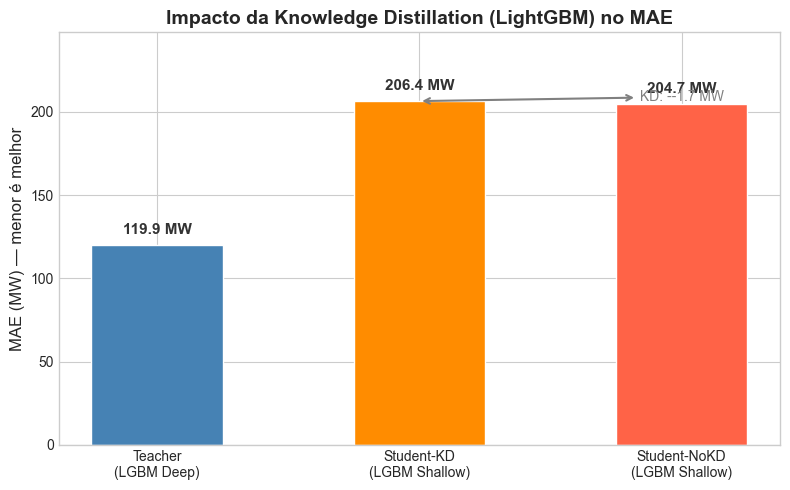

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

modelos = ['Teacher\n(LGBM Deep)', 'Student-KD\n(LGBM Shallow)', 'Student-NoKD\n(LGBM Shallow)']
maes = [mae_teacher, mae_kd, mae_nokd]
cores = ['steelblue', 'darkorange', 'tomato']

bars = ax.bar(modelos, maes, color=cores, width=0.5, edgecolor='white')

for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.1f} MW", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Adiciona anotação de ganho da KD
kd_gain = mae_nokd - mae_kd
ax.annotate(f"KD: -{kd_gain:.1f} MW",
            xy=(1, mae_kd),
            xytext=(2, mae_nokd),
            arrowprops=dict(arrowstyle="<->", color="gray", lw=1.5),
            ha='center', va='bottom', fontsize=10, color='gray')

ax.set_ylim(0, max(maes) * 1.2)
ax.set_title('Impacto da Knowledge Distillation (LightGBM) no MAE', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE (MW) — menor é melhor', fontsize=12)
plt.tight_layout()
plt.show()
